# Gradient Variance -- HEA & QAOA (extra ansätze)

Chỉ tính 2 ansatz mới (**HEA** L=2, **QAOA** p=2) trên 5 init, CÙNG dải qubit với `GV_5_Initializations`, xuất `gv_5inits_extra.json`.

Cell cuối merge với `gv_5inits.json` (IQP: single/circular/full đã chạy) để vẽ **5 đường/subplot** -- KHÔNG chạy lại IQP.

In [ ]:
import json
import numpy as np
import pennylane as qp
from pennylane import numpy as qnp
import matplotlib.pyplot as plt

from ansatz_extra import apply_ansatz, n_params_for, init_params
from IQP_circuit_pennylane import binary_ops_to_hamiltonian, hamiltonian_data

## Patch `ising_obs` (giong GV goc)
`ising_obs` khong ship trong `IQP_circuit`, nen dinh nghia va inject vao module de `hamiltonian_data` dung duoc cho mode 'ising'.

In [ ]:
def ising_obs(n_qubits, corr=2):
    observables = []
    for i in range(n_qubits):
        v = [0] * n_qubits; v[i] = 1; observables.append(v)
    if corr == 2:
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                v = [0] * n_qubits; v[i] = 1; v[j] = 1; observables.append(v)
    return np.array(observables, dtype=int)

import IQP_circuit_pennylane
IQP_circuit_pennylane.ising_obs = ising_obs

## Uoc luong gradient variance (flat / exact)
Var qua `n_trials` init ngau nhien, trung binh tren cac tham so. Dung vector phang + `apply_ansatz` cho HEA/QAOA.

In [ ]:
def gradient_variance_flat(ops, coeffs, n, ansatz, spec, init_name, n_trials=100):
    H = binary_ops_to_hamiltonian(ops, coeffs)
    dev = qp.device("lightning.qubit", wires=n, shots=None)

    def circ(params):
        apply_ansatz(params, ops, coeffs, n, ansatz, spec)
        return qp.expval(H)

    qnode = qp.QNode(circ, dev, interface="autograd")
    grad_fn = qp.grad(qnode)
    m = n_params_for(ansatz, spec, n)
    grads = []
    for _ in range(n_trials):
        p = qnp.array(init_params(init_name, m, n), requires_grad=True)
        grads.append(np.asarray(grad_fn(p)))
    grads = np.array(grads)
    return float(np.mean(np.var(grads, axis=0)))

## Load datasets (cung file voi GV goc)

In [ ]:
with open("ising.json", "r") as f:
    dataset_ising = {int(k): v for k, v in json.load(f).items()}
with open("maxcut.json", "r") as f:
    dataset_maxcut = {int(k): v for k, v in json.load(f).items()}
with open("partition.json", "r") as f:
    dataset_partition = {int(k): v for k, v in json.load(f).items()}

dataset = {'ising': dataset_ising, 'maxcut': dataset_maxcut, 'partition': dataset_partition}
print("Dataset loaded successfully")

Dataset loaded successfully


## Tinh GV cho HEA & QAOA
CUNG `qubits`, `inits`, `mode_hamiltonians` voi file cu de merge khop. Key tang circuit = `'hea'` / `'qaoa'`.

> **Chi phi:** exact 2**n x 5 init x 2 ansatz; goc nang nhat la n=18. Thu nho truoc voi `qubits=[3,6]`, `n_problem=2`, `n_trials=20` de sanity-check, roi moi chay full.

In [ ]:
inits             = ['normal', 'uniform', 'pi4', 'he', 'glorot']
mode_hamiltonians = ['ising', 'maxcut', 'partition']
ansatz_configs    = [('hea', 2), ('qaoa', 2)]   # label tang circuit = ten ansatz
qubits            = [3, 6, 9, 12, 15, 18]
n_problem         = 10
n_trials          = 100

np.random.seed(42)
all_extra = {}
for init_name in inits:
    print(f"\n{'='*40}\nInit: {init_name}")
    results = {}
    for mode_ham in mode_hamiltonians:
        print(f"  === {mode_ham} ===")
        results[mode_ham] = {}
        for ansatz, spec in ansatz_configs:
            key = ansatz  # 'hea' / 'qaoa'
            print(f"    {key}")
            results[mode_ham][key] = {}
            for n_qubits in qubits:
                print(f"      n={n_qubits}", end=" ... ", flush=True)
                grad_vars = []
                for pid in range(n_problem):
                    ops, coeffs = hamiltonian_data(
                        dataset[mode_ham][n_qubits][pid], n_qubits, mode_ham)
                    v = gradient_variance_flat(
                        ops, coeffs, n_qubits, ansatz, spec, init_name, n_trials=n_trials)
                    grad_vars.append(v)
                results[mode_ham][key][n_qubits] = grad_vars
                print(f"mean={np.mean(grad_vars):.2e}")
    all_extra[init_name] = results

with open("gv_5inits_extra.json", "w") as f:
    json.dump(all_extra, f, indent=4)
print("\nSaved to gv_5inits_extra.json")

## Merge voi IQP + ve 5 ansatz
Load `gv_5inits.json` (IQP: single/circular/full) va `gv_5inits_extra.json` (hea/qaoa), ghep o tang circuit roi ve 3x5, moi subplot 5 duong (scale rieng theo max).

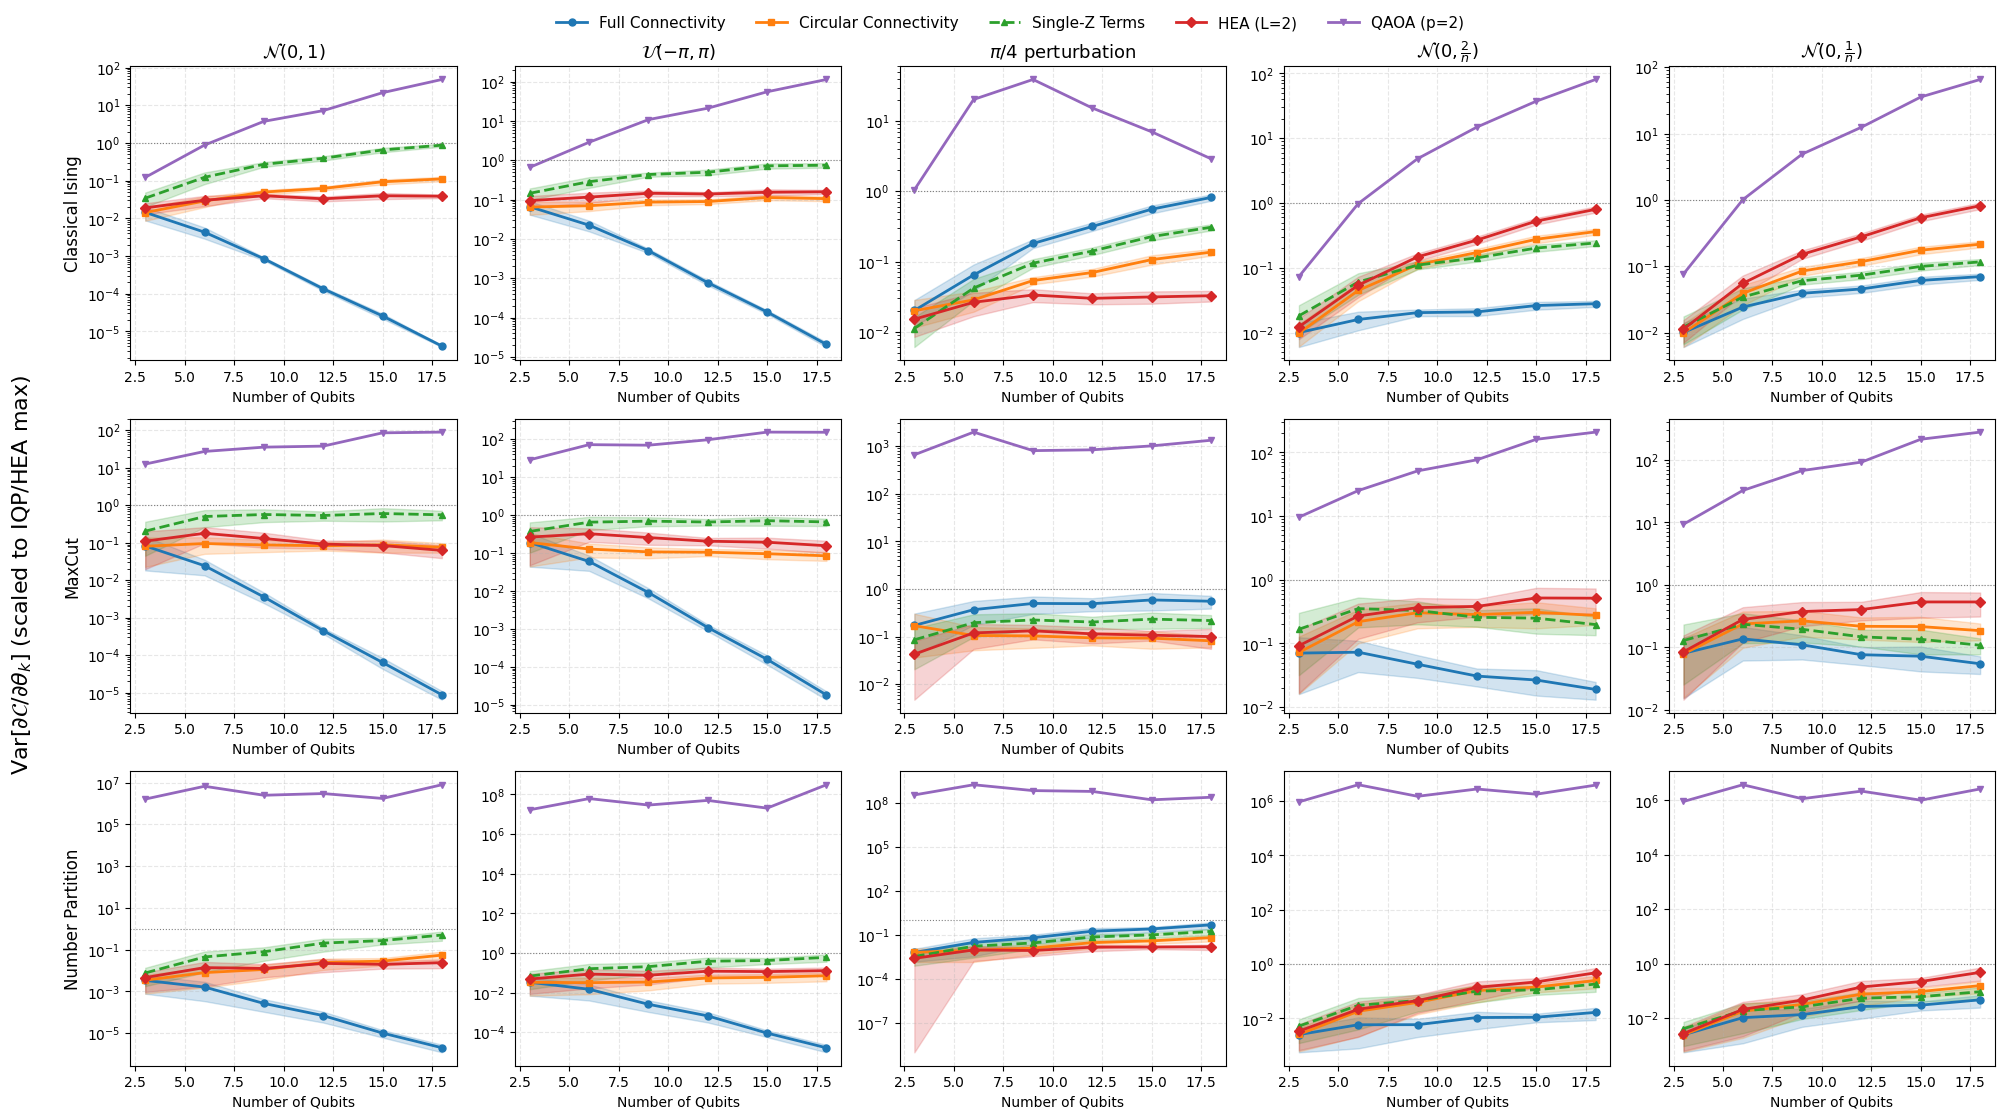

In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np

with open("gv_5inits.json", "r") as f:
    base = json.load(f)        # IQP: single / circular / full
with open("gv_5inits_extra.json", "r") as f:
    extra = json.load(f)       # hea / qaoa

# merge: them hea/qaoa vao tang circuit cua tung (init, ham)
merged = {}
for init_name in base:
    merged[init_name] = {}
    for ham in base[init_name]:
        merged[init_name][ham] = dict(base[init_name][ham])
        merged[init_name][ham].update(extra[init_name][ham])

qubits = [3, 6, 9, 12, 15, 18]
ham_names = {'ising': 'Classical Ising', 'maxcut': 'MaxCut', 'partition': 'Number Partition'}
order     = ['full', 'circular', 'single', 'hea', 'qaoa']
# QAOA co Var tho lon hon nhieu bac (params gamma,beta nhan ca Hamiltonian) va
# khong cung "don vi" voi goc tung cong cua IQP/HEA -> LOAI khoi phep chuan hoa,
# de 4 ansatz kia giu dung dynamic range; QAOA se troi len tren moc 1 (illustrative).
scale_set = ['full', 'circular', 'single', 'hea']
styles = {'full': ('o-', '#1f77b4'), 'circular': ('s-', '#ff7f0e'), 'single': ('^--', '#2ca02c'),
          'hea': ('D-', '#d62728'), 'qaoa': ('v-', '#9467bd')}
labels = {'full': 'Full Connectivity', 'circular': 'Circular Connectivity',
          'single': 'Single-Z Terms', 'hea': 'HEA (L=2)', 'qaoa': 'QAOA (p=2)'}
init_cols  = ['normal', 'uniform', 'pi4', 'he', 'glorot']
col_titles = {'normal': r'$\mathcal{N}(0, 1)$', 'uniform': r'$\mathcal{U}(-\pi, \pi)$',
              'pi4': r'$\pi/4$ perturbation', 'he': r'$\mathcal{N}(0, \frac{2}{n})$',
              'glorot': r'$\mathcal{N}(0, \frac{1}{n})$'}

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for row, ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax  = axes[row][col]
        res = merged[init_name][ham]
        # scale = max cua 4 ansatz (khong tinh QAOA)
        scale = max(v for mc in scale_set for n in qubits for v in res[mc][str(n)])
        for mc in order:
            means = np.array([np.mean(res[mc][str(n)]) for n in qubits]) / scale
            stds  = np.array([np.std(res[mc][str(n)])  for n in qubits]) / scale
            fmt, color = styles[mc]
            ax.plot(qubits, means, fmt, color=color, label=labels[mc], linewidth=2, markersize=5)
            if mc != 'qaoa':   # QAOA std qua lon (illustrative) -> chi ve duong mean
                lower = np.clip(means - stds, 1e-9, None)   # tranh log-fill vo khi mean-std<0
                ax.fill_between(qubits, lower, means + stds, color=color, alpha=0.2)
        ax.axhline(1.0, color='gray', ls=':', lw=0.8)   # moc = max cua IQP/HEA
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')
        if col == 0:
            ax.set_ylabel(ham_names[ham], fontsize=12)
        if row == 0:
            ax.set_title(col_titles[init_name], fontsize=13)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=5,
           bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=11)
fig.supylabel(r'$\mathrm{Var}\left[\partial \mathcal{C}/\partial \theta_k\right]$ (scaled to IQP/HEA max)', fontsize=16, x=0.0)
plt.tight_layout()
plt.savefig("GV_5_initializations_5ansatz.pdf", dpi=300, bbox_inches='tight')
plt.show()

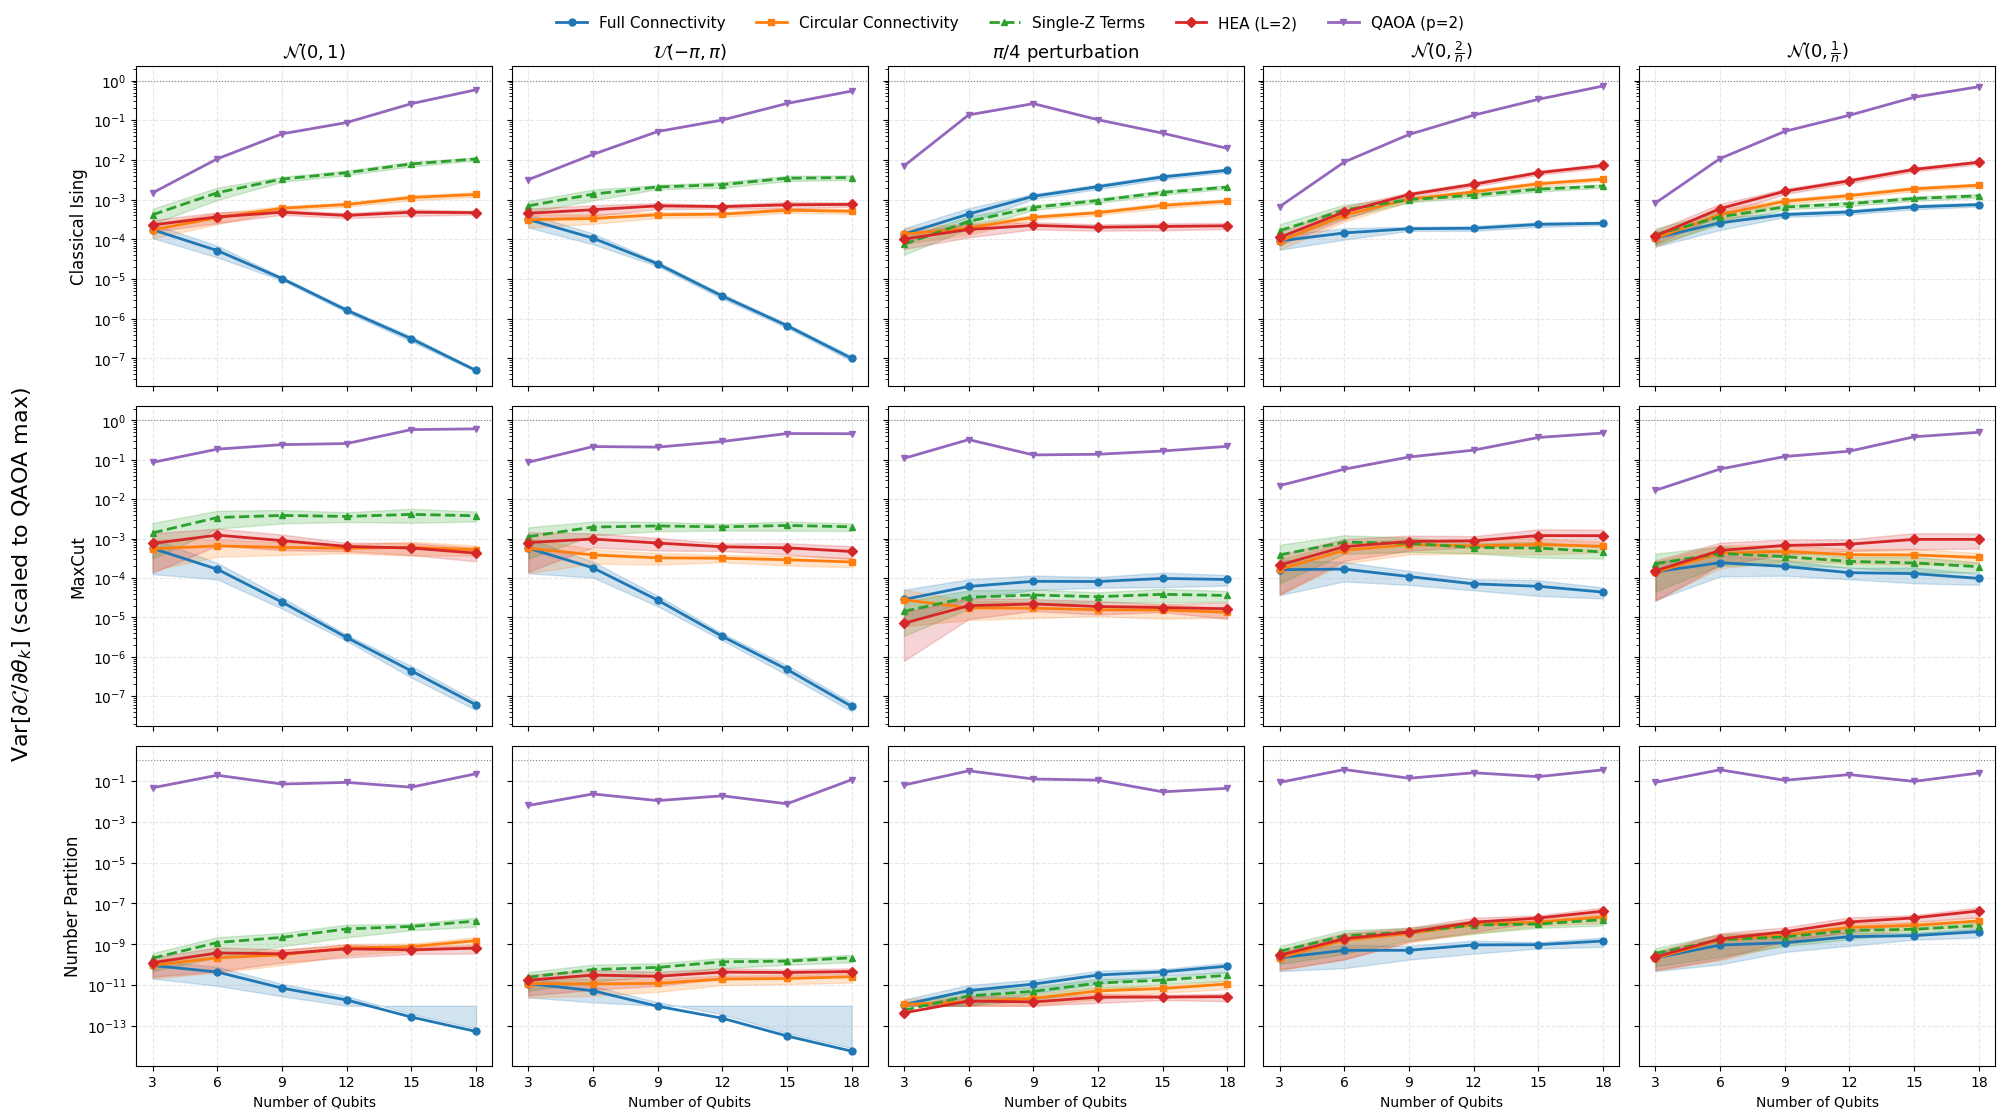

In [2]:
# === Bien the: scale theo QAOA (QAOA ~1 o dinh, ca ho IQP/HEA nam duoi) ===
# CHAY SAU cell merge o tren: dung lai merged, order, styles, labels, init_cols,
# col_titles, ham_names, qubits.
# Muc dich: nhin ro do chenh MAGNITUDE giua QAOA va ho IQP/HEA
# (QAOA generator = ca H -> Var ~ ||H||^2; ro nhat o Number Partition, ||H||~1e5).
fig, axes = plt.subplots(3, 5, figsize=(20, 11), sharex=True, sharey='row')
for row, ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax  = axes[row][col]
        res = merged[init_name][ham]
        scale = max(v for n in qubits for v in res['qaoa'][str(n)])   # scale theo QAOA max
        for mc in order:
            means = np.array([np.mean(res[mc][str(n)]) for n in qubits]) / scale
            stds  = np.array([np.std(res[mc][str(n)])  for n in qubits]) / scale
            fmt, color = styles[mc]
            ax.plot(qubits, means, fmt, color=color, label=labels[mc], linewidth=2, markersize=5)
            if mc != 'qaoa':   # QAOA std qua lon -> chi ve mean
                lower = np.clip(means - stds, 1e-12, None)
                ax.fill_between(qubits, lower, means + stds, color=color, alpha=0.2)
        ax.axhline(1.0, color='gray', ls=':', lw=0.8)   # moc = max cua QAOA
        ax.set_yscale('log')
        ax.set_xticks(qubits)                 # tick = dung cac gia tri n da chay, khong co 2.5/3.5
        ax.grid(True, alpha=0.3, linestyle='--')
        if row == 2:                          # xlabel chi o hang duoi cung
            ax.set_xlabel('Number of Qubits')
        if col == 0:
            ax.set_ylabel(ham_names[ham], fontsize=12)
        if row == 0:
            ax.set_title(col_titles[init_name], fontsize=13)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=5,
           bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=11)
fig.supylabel(r'$\mathrm{Var}\left[\partial \mathcal{C}/\partial \theta_k\right]$ (scaled to QAOA max)', fontsize=16, x=0.0)
plt.tight_layout()
plt.savefig("GV_5_initializations_5ansatz_qaoascale.pdf", dpi=300, bbox_inches='tight')
plt.show()